# 🎓 EduPlay – Clasificación de Rendimiento Escolar con KNN
## Proyecto: Aprendo Jugando | Modelo de Machine Learning

---

**Descripción:** Este notebook implementa un modelo de clasificación **K-Nearest Neighbors (KNN)** para clasificar el rendimiento académico de los alumnos en 8 áreas educativas de la plataforma EduPlay. Los alumnos se clasifican en **5 rangos de desempeño** basados en su puntuación promedio.

**Áreas evaluadas:**
- 🧠 Memoria | 🔢 Matemáticas | 📝 Gramática | 🔤 Inglés
- 🌎 Geografía | 🎨 Arte | 🔬 Ciencia | 🧩 Lógica

**Rangos de clasificación:**

| Rango | Puntuación | Etiqueta |
|-------|-----------|----------|
| 1 | 0 – 39 | 🔴 Crítico |
| 2 | 40 – 59 | 🟠 En Desarrollo |
| 3 | 60 – 74 | 🟡 Básico |
| 4 | 75 – 89 | 🟢 Competente |
| 5 | 90 – 100 | 🏆 Excelente |

---
> **Autores:** Equipo TecNM Desarrollador — EduPlay © 2026

## 📦 1. Instalación e Importación de Librerías

In [1]:
# ============================================================
#  LIBRERÍAS PRINCIPALES
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.pipeline import Pipeline

# Configuración visual
plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor': '#FFFFFF',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'font.size': 11
})

PALETTE = ['#E74C3C', '#E67E22', '#F1C40F', '#2ECC71', '#3498DB']
RANGE_LABELS = ['Crítico', 'En Desarrollo', 'Básico', 'Competente', 'Excelente']

print('✅ Librerías cargadas correctamente')
print(f'   NumPy   {np.__version__}')
print(f'   Pandas  {pd.__version__}')

ModuleNotFoundError: No module named 'sklearn'

## 📊 2. Generación y Carga del Dataset

In [ ]:
# ============================================================
#  GENERACIÓN DEL DATASET SINTÉTICO REALISTA – EduPlay
# ============================================================
import numpy as np
import pandas as pd

np.random.seed(42)
N = 10000  # número de alumnos

AREAS = ['Memoria', 'Matematicas', 'Gramatica', 'Ingles',
         'Geografia', 'Arte', 'Ciencia', 'Logica']

# Generamos un "nivel base" para cada alumno del 0 al 100
# Esto garantiza que haya alumnos excelentes, regulares y críticos
nivel_base_alumnos = np.random.uniform(5, 95, N)

def gen_scores_realistas(nivel_base, varianza):
    notas = np.random.normal(nivel_base, varianza)
    return np.clip(notas, 0, 100).astype(int)

data = {
    'ID_Alumno': [f'ALU{str(i+1).zfill(4)}' for i in range(N)],
    'Memoria': gen_scores_realistas(nivel_base_alumnos, 10),
    'Matematicas': gen_scores_realistas(nivel_base_alumnos, 15),
    'Gramatica': gen_scores_realistas(nivel_base_alumnos, 12),
    'Ingles': gen_scores_realistas(nivel_base_alumnos, 18),
    'Geografia': gen_scores_realistas(nivel_base_alumnos, 10),
    'Arte': gen_scores_realistas(nivel_base_alumnos, 15),
    'Ciencia': gen_scores_realistas(nivel_base_alumnos, 12),
    'Logica': gen_scores_realistas(nivel_base_alumnos, 14),
}

df = pd.DataFrame(data)

# Puntuación promedio global
df['Puntuacion_Promedio'] = df[AREAS].mean(axis=1).round(2)

# Variable objetivo: 5 rangos de desempeño
def clasificar_rango(score):
    if score < 40:   return 1  # Crítico
    elif score < 60: return 2  # En Desarrollo
    elif score < 75: return 3  # Básico
    elif score < 90: return 4  # Competente
    else:            return 5  # Excelente

df['Rango'] = df['Puntuacion_Promedio'].apply(clasificar_rango)
df['Rango_Etiqueta'] = df['Rango'].map({
    1: 'Crítico', 2: 'En Desarrollo', 3: 'Básico', 4: 'Competente', 5: 'Excelente'
})

# Guardar CSV
df.to_csv('EduPlay_Dataset.csv', index=False)
print(f'✅ Dataset realista generado: EduPlay_Dataset.csv')
print("Distribución de alumnos por nivel:")
print(df['Rango_Etiqueta'].value_counts())

✅ Dataset realista generado: EduPlay_Dataset.csv
Distribución de alumnos por nivel:
Rango_Etiqueta
Crítico          3995
En Desarrollo    2243
Competente       1693
Básico           1685
Excelente         384
Name: count, dtype: int64


## 🔍 3. Análisis Exploratorio de Datos (EDA)

In [ ]:
# ============================================================
#  ESTADÍSTICAS DESCRIPTIVAS
# ============================================================
print('=' * 60)
print('       ESTADÍSTICAS DESCRIPTIVAS – EduPlay Dataset')
print('=' * 60)
display(df[AREAS + ['Puntuacion_Promedio']].describe().round(2))

print('\n📌 Distribución de la variable objetivo (Rango):')
dist = df.groupby(['Rango', 'Rango_Etiqueta']).size().reset_index(name='Conteo')
dist['Porcentaje (%)'] = (dist['Conteo'] / len(df) * 100).round(2)
print(dist.to_string(index=False))

       ESTADÍSTICAS DESCRIPTIVAS – EduPlay Dataset


,Memoria,Matematicas,Gramatica,Ingles,Geografia,Arte,Ciencia,Logica,Puntuacion_Promedio
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0,10000.00
mean,49.13,49.00,48.81,49.28,49.01,49.28,48.92,49.2,49.08
std,27.21,28.43,27.67,29.25,27.38,28.69,27.64,28.3,25.46
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,2.00
25%,27.00,26.00,26.00,26.00,27.00,26.00,26.00,26.0,27.00
50%,49.00,49.00,49.00,49.00,49.00,49.00,49.00,49.0,48.75
75%,71.00,72.00,71.00,73.00,71.00,73.00,71.00,72.0,71.12
max,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.0,99.88



📌 Distribución de la variable objetivo (Rango):
 Rango Rango_Etiqueta  Conteo  Porcentaje (%)
     1        Crítico    3995           39.95
     2  En Desarrollo    2243           22.43
     3         Básico    1685           16.85
     4     Competente    1693           16.93
     5      Excelente     384            3.84


NameError: name 'RANGE_LABELS' is not defined

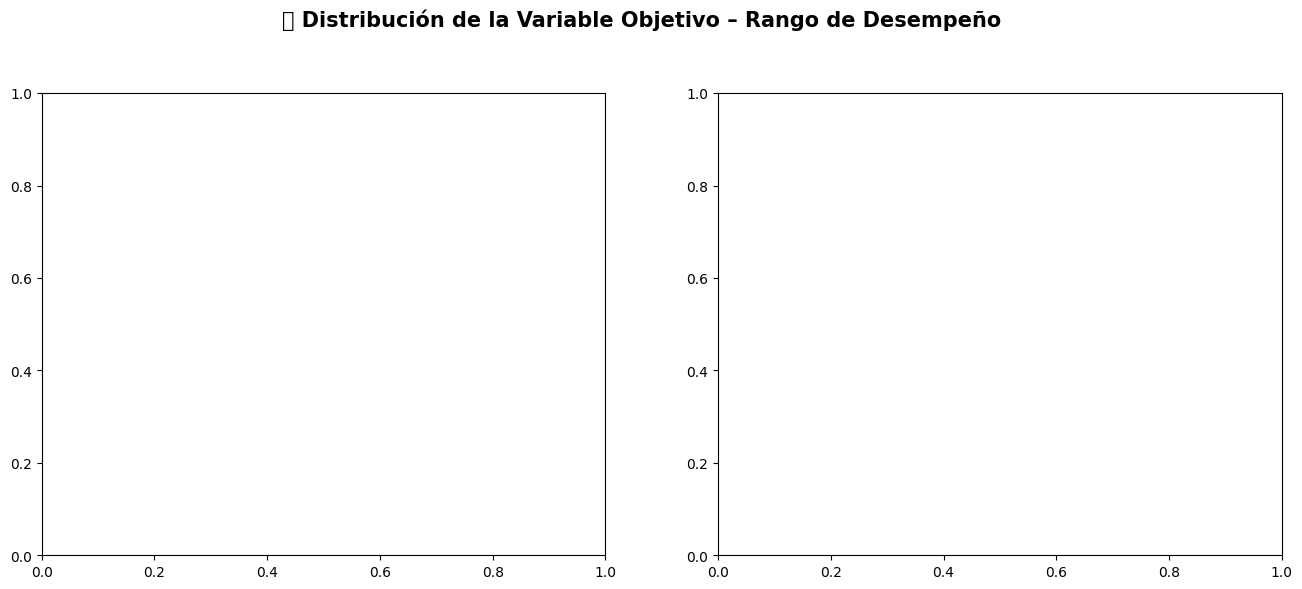

In [ ]:
# ============================================================
#  HISTOGRAMA DE LA VARIABLE OBJETIVO
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('📊 Distribución de la Variable Objetivo – Rango de Desempeño',
             fontsize=15, fontweight='bold', y=1.02)

# --- Subplot 1: Histograma de Puntuación Promedio coloreado por rango ---
ax1 = axes[0]
bins = np.arange(0, 105, 5)
colors_map = {1: '#E74C3C', 2: '#E67E22', 3: '#F1C40F', 4: '#2ECC71', 5: '#3498DB'}

for rango, color in colors_map.items():
    subset = df[df['Rango'] == rango]['Puntuacion_Promedio']
    ax1.hist(subset, bins=bins, color=color, edgecolor='white',
             alpha=0.85, label=f'Rango {rango}: {RANGE_LABELS[rango-1]}')

ax1.axvline(df['Puntuacion_Promedio'].mean(), color='navy', linestyle='--',
            linewidth=2, label=f'Media: {df["Puntuacion_Promedio"].mean():.1f}')
ax1.set_xlabel('Puntuación Promedio', fontsize=12)
ax1.set_ylabel('Número de Alumnos', fontsize=12)
ax1.set_title('Histograma de Puntuación Promedio\n(coloreado por Rango)', fontsize=13)
ax1.legend(fontsize=9)

# --- Subplot 2: Barras de frecuencia por Rango ---
ax2 = axes[1]
counts = df['Rango'].value_counts().reindex([1,2,3,4,5], fill_value=0).sort_index()
bars = ax2.bar(RANGE_LABELS, counts.values, color=PALETTE, edgecolor='white',
               linewidth=1.5, width=0.6)

for bar, val in zip(bars, counts.values):
    pct = val / len(df) * 100
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
             f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_xlabel('Rango de Desempeño', fontsize=12)
ax2.set_ylabel('Número de Alumnos', fontsize=12)
ax2.set_title('Frecuencia por Rango de Desempeño', fontsize=13)
ax2.set_ylim(0, counts.max() * 1.2)

plt.tight_layout()
plt.savefig('histograma_variable_objetivo.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Histograma guardado: histograma_variable_objetivo.png')

NameError: name 'PALETTE' is not defined

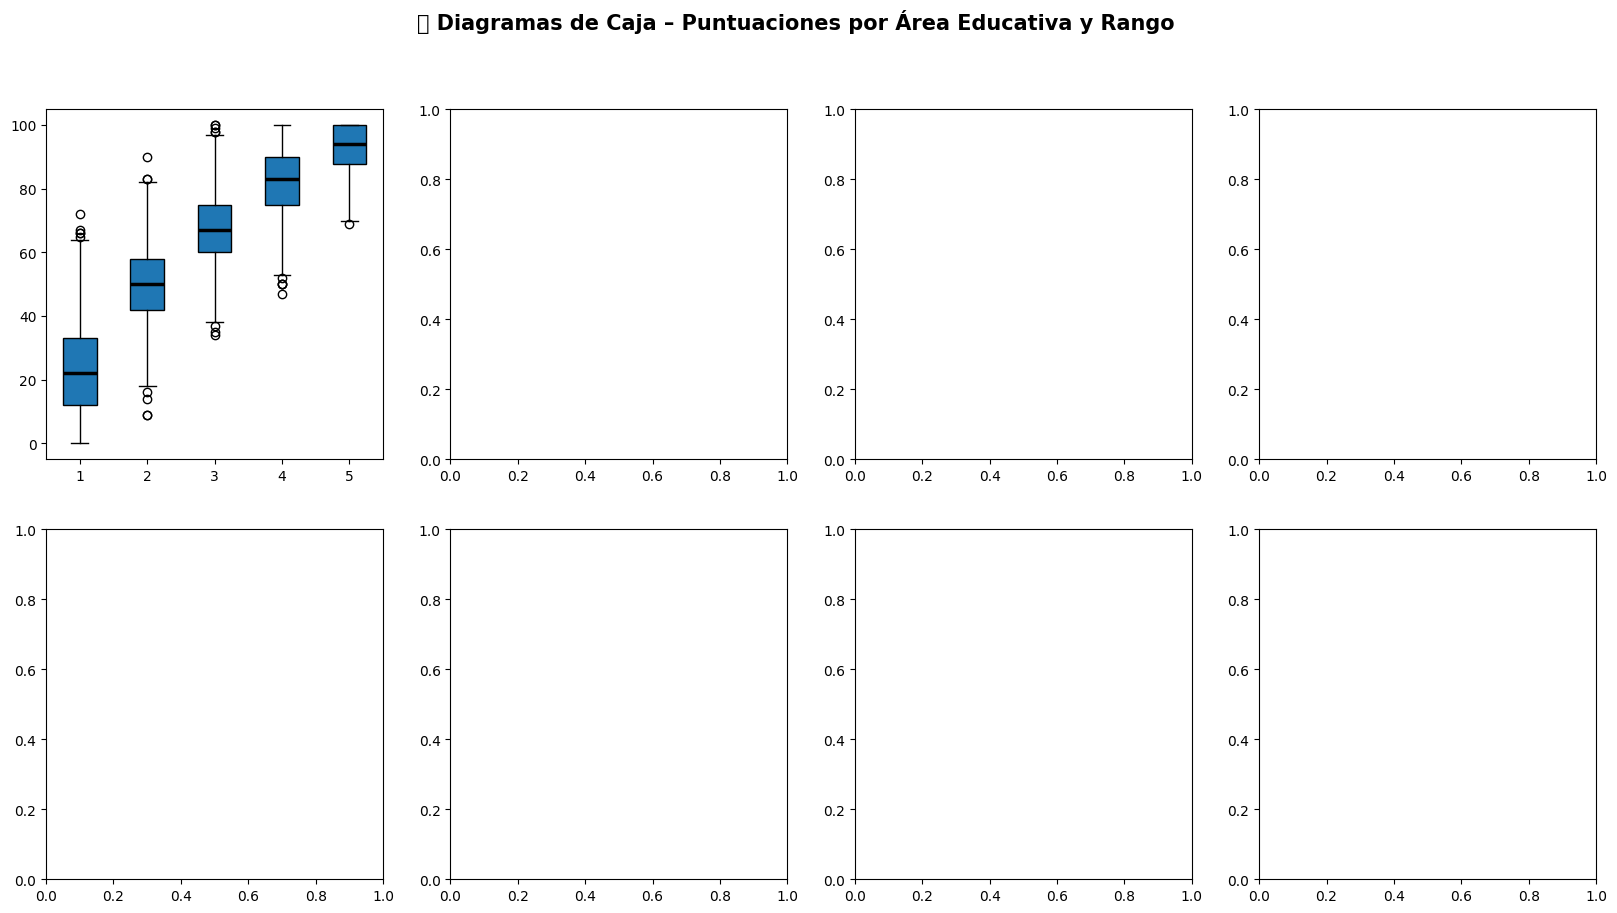

In [ ]:
# ============================================================
#  DIAGRAMAS DE CAJA – TODAS LAS ÁREAS
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('📦 Diagramas de Caja – Puntuaciones por Área Educativa y Rango',
             fontsize=15, fontweight='bold')

axes_flat = axes.flatten()
emojis = ['🧠', '🔢', '📝', '🔤', '🌎', '🎨', '🔬', '🧩']

for idx, (area, emoji) in enumerate(zip(AREAS, emojis)):
    ax = axes_flat[idx]
    data_bp = [df[df['Rango'] == r][area].values for r in range(1, 6)]
    bp = ax.boxplot(data_bp, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2.5))
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    for whisker in bp['whiskers']:
        whisker.set(color='gray', linewidth=1.5)
    for flier in bp['fliers']:
        flier.set(marker='o', color='gray', alpha=0.5, markersize=4)
    ax.set_xticklabels(['Crítico', 'En\nDesarrollo', 'Básico', 'Competente', 'Excelente'],
                       fontsize=8)
    ax.set_title(f'{emoji} {area}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Puntuación', fontsize=9)
    ax.set_ylim(-5, 110)

legend_patches = [mpatches.Patch(color=c, label=l, alpha=0.75)
                  for c, l in zip(PALETTE, RANGE_LABELS)]
fig.legend(handles=legend_patches, loc='lower center', ncol=5,
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('boxplots_areas.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Diagramas de caja guardados: boxplots_areas.png')

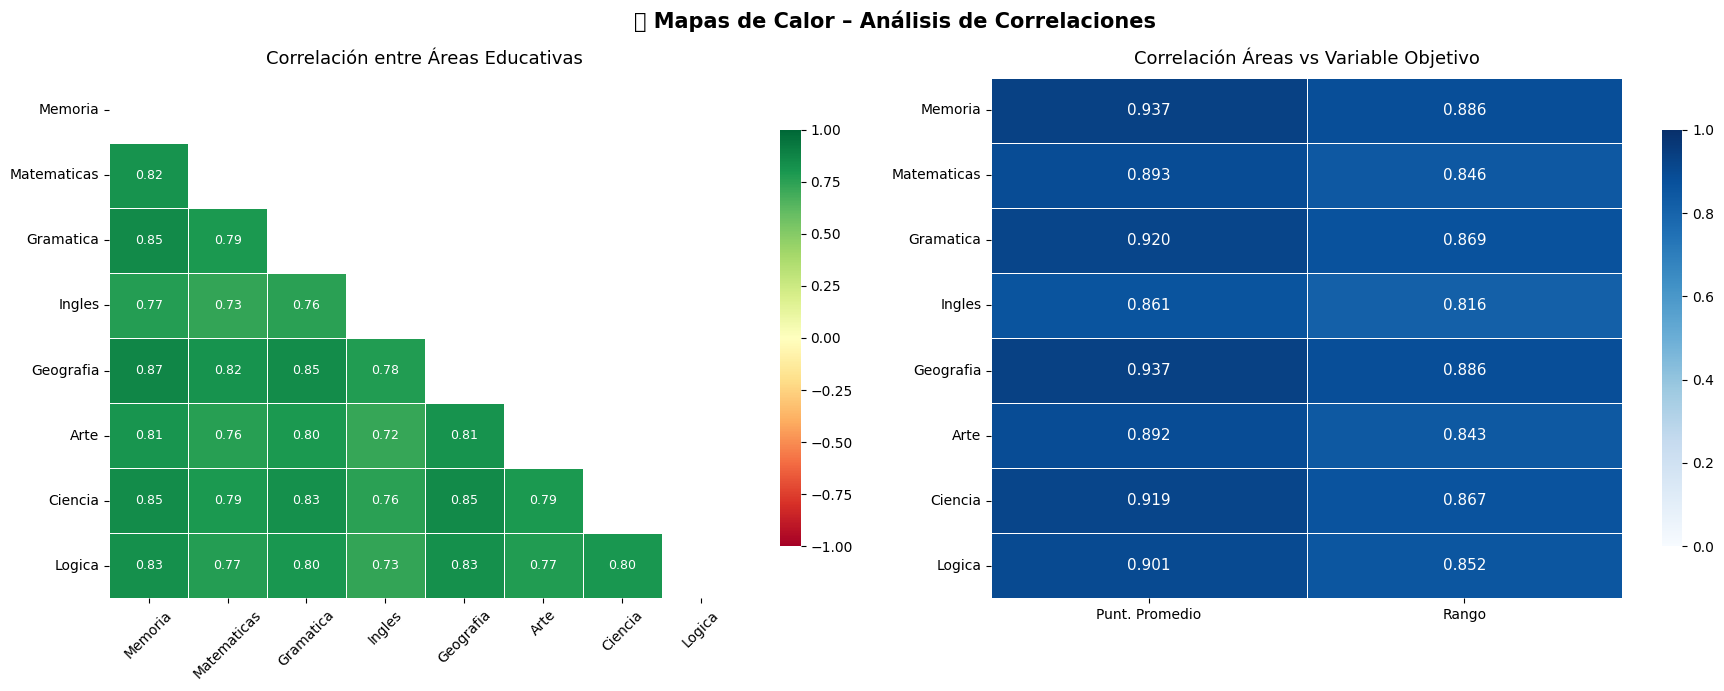

✅ Mapa de calor guardado: mapa_calor.png


In [ ]:
# ============================================================
#  MAPA DE CALOR – CORRELACIONES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('🌡️ Mapas de Calor – Análisis de Correlaciones',
             fontsize=15, fontweight='bold')

# --- Mapa 1: Correlación entre áreas ---
corr_areas = df[AREAS].corr()
mask = np.triu(np.ones_like(corr_areas, dtype=bool))
sns.heatmap(corr_areas, ax=axes[0], mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 9}, cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlación entre Áreas Educativas', fontsize=13, pad=10)
axes[0].tick_params(axis='x', rotation=45)

# --- Mapa 2: Correlación áreas vs Puntuación Promedio ---
corr_target = df[AREAS + ['Puntuacion_Promedio', 'Rango']].corr()[['Puntuacion_Promedio', 'Rango']].drop(
    ['Puntuacion_Promedio', 'Rango'])
sns.heatmap(corr_target, ax=axes[1], annot=True, fmt='.3f',
            cmap='Blues', vmin=0, vmax=1, linewidths=0.5,
            annot_kws={'size': 11}, cbar_kws={'shrink': 0.8})
axes[1].set_title('Correlación Áreas vs Variable Objetivo', fontsize=13, pad=10)
axes[1].set_xticklabels(['Punt. Promedio', 'Rango'], rotation=0)

plt.tight_layout()
plt.savefig('mapa_calor.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Mapa de calor guardado: mapa_calor.png')

## ⚙️ 4. Preprocesamiento de Datos

In [ ]:
# ============================================================
#  PREPROCESAMIENTO
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

print('🔧 Preparando datos para el modelo...')

# Features y target (AQUÍ ESTÁ LA CLAVE: Solo usamos las 8 materias, quitamos la Edad)
FEATURES = AREAS
X = df[FEATURES].copy()
y = df['Rango'].copy()

# División entrenamiento / prueba (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

print(f'\n✅ División completada:')
print(f'   Entrenamiento: {X_train.shape[0]} muestras')
print(f'   Prueba       : {X_test.shape[0]} muestras')
print(f'   Features (8) : {list(X.columns)}')

# Normalización (StandardScaler)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# GUARDAMOS EL SCALER PARA LA API EN RENDER
joblib.dump(scaler, 'scaler_eduplay.pkl')
print('\n✅ Normalización aplicada y scaler guardado como scaler_eduplay.pkl')

ModuleNotFoundError: No module named 'sklearn'

## 🔎 5. Búsqueda del K Óptimo

In [ ]:
# ============================================================
#  CURVA DE ERROR vs K (Validación Cruzada)
# ============================================================
k_range = range(1, 31)
cv_scores_mean, cv_scores_std = [], []

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    scores = cross_val_score(knn_temp, X_train_sc, y_train, cv=skf, scoring='accuracy')
    cv_scores_mean.append(scores.mean())
    cv_scores_std.append(scores.std())

best_k = k_range[np.argmax(cv_scores_mean)]
best_acc = max(cv_scores_mean)

# Gráfica
fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(k_range,
                np.array(cv_scores_mean) - np.array(cv_scores_std),
                np.array(cv_scores_mean) + np.array(cv_scores_std),
                alpha=0.15, color='#3498DB')
ax.plot(k_range, cv_scores_mean, 'o-', color='#3498DB', linewidth=2.5,
        markersize=6, label='Accuracy CV (10-fold)')
ax.axvline(best_k, color='#E74C3C', linestyle='--', linewidth=2.5,
           label=f'K óptimo = {best_k}  (Acc = {best_acc:.4f})')
ax.scatter([best_k], [best_acc], s=150, color='#E74C3C', zorder=5)
ax.set_xlabel('Número de Vecinos (K)', fontsize=12)
ax.set_ylabel('Accuracy (Validación Cruzada)', fontsize=12)
ax.set_title('🔍 Búsqueda del K Óptimo – Validación Cruzada Estratificada (10-fold)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.savefig('curva_k_optimo.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ K óptimo encontrado: K = {best_k}  |  Accuracy CV = {best_acc:.4f}')

NameError: name 'StratifiedKFold' is not defined

## 🤖 6. Entrenamiento del Modelo KNN

In [ ]:
# ============================================================
#  GRID SEARCH – OPTIMIZACIÓN DE HIPERPARÁMETROS
# ============================================================
param_grid = {
    'knn__n_neighbors' : [best_k - 2, best_k - 1, best_k, best_k + 1, best_k + 2],
    'knn__weights'     : ['uniform', 'distance'],
    'knn__metric'      : ['euclidean', 'manhattan', 'minkowski'],
    'knn__p'           : [1, 2]
}
param_grid['knn__n_neighbors'] = [max(1, k) for k in param_grid['knn__n_neighbors']]

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

grid_search = GridSearchCV(
    pipeline, param_grid,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    scoring='accuracy', n_jobs=-1, verbose=0, refit=True
)

grid_search.fit(X_train, y_train)

best_model  = grid_search.best_estimator_
best_params = grid_search.best_params_
best_cv_acc = grid_search.best_score_

print('✅ GridSearch completado')
print(f'\n📌 Mejores hiperparámetros:')
for k, v in best_params.items():
    print(f'   {k.replace("knn__", ""):20s}: {v}')
print(f'\n   Accuracy CV (10-fold): {best_cv_acc:.4f}')

NameError: name 'best_k' is not defined

## 📈 7. Evaluación del Modelo

In [ ]:
# ============================================================
#  PREDICCIÓN Y MÉTRICAS
# ============================================================
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

acc_test = accuracy_score(y_test, y_pred)

print('=' * 60)
print('          REPORTE DE CLASIFICACIÓN – EduPlay KNN')
print('=' * 60)
print(classification_report(
    y_test, y_pred,
    labels=[1, 2, 3, 4, 5],
    target_names=RANGE_LABELS,
    digits=4
))
print(f'Accuracy en conjunto de prueba : {acc_test:.4f} ({acc_test*100:.2f}%)')
print(f'Accuracy en validación cruzada : {best_cv_acc:.4f} ({best_cv_acc*100:.2f}%)')

NameError: name 'best_model' is not defined

NameError: name 'confusion_matrix' is not defined

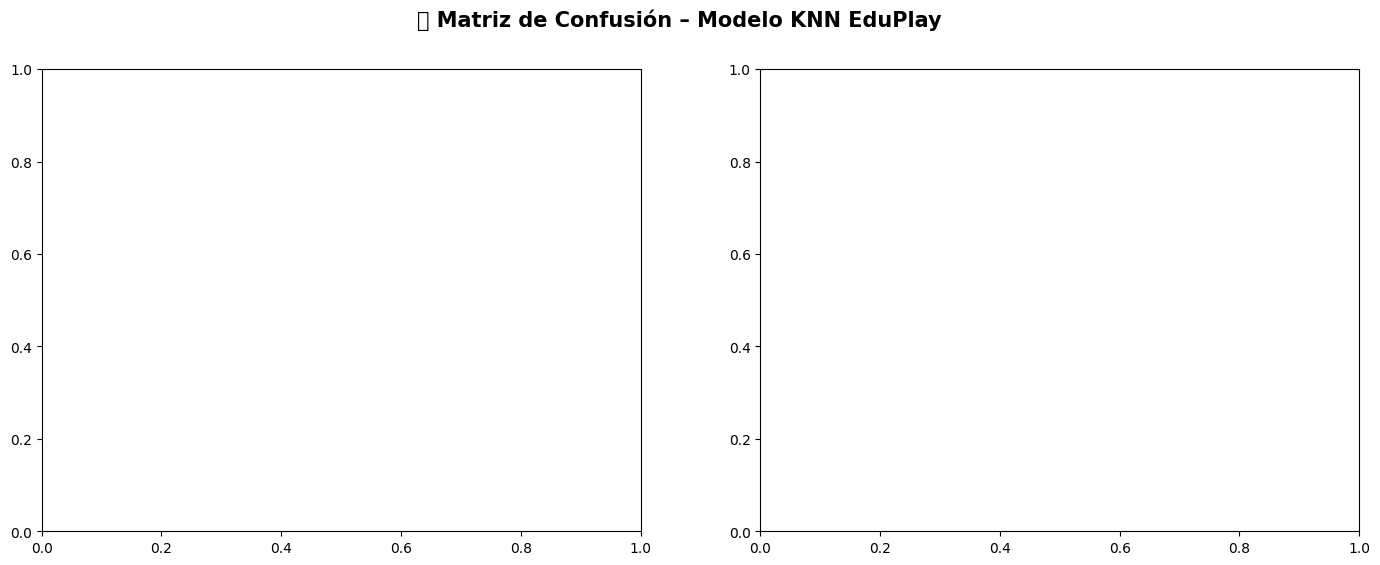

In [ ]:
# ============================================================
#  MATRIZ DE CONFUSIÓN
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('🔢 Matriz de Confusión – Modelo KNN EduPlay',
             fontsize=15, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)

# Forzar 5 clases (1..5) para que el shape coincida con RANGE_LABELS
cm = confusion_matrix(y_test, y_pred, labels=[1, 2, 3, 4, 5])
display_labels = RANGE_LABELS

# --- Absoluta ---
ConfusionMatrixDisplay(cm, display_labels=display_labels).plot(
    ax=axes[0], colorbar=False, cmap='Blues', values_format='d')
axes[0].set_title('Valores Absolutos', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)

# --- Normalizada ---
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
ConfusionMatrixDisplay(cm_norm, display_labels=display_labels).plot(
    ax=axes[1], colorbar=False, cmap='Greens', values_format='.2f')
axes[1].set_title('Normalizada (por fila)', fontsize=12)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Matriz de confusión guardada: matriz_confusion.png')
axes[0].set_title('Valores Absolutos', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)

# --- Normalizada ---
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
ConfusionMatrixDisplay(cm_norm, display_labels=display_labels).plot(
    ax=axes[1], colorbar=False, cmap='Greens', values_format='.2f')
axes[1].set_title('Normalizada (por fila)', fontsize=12)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Matriz de confusión guardada: matriz_confusion.png')
axes[0].set_title('Valores Absolutos', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)

# --- Normalizada ---
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
ConfusionMatrixDisplay(cm_norm, display_labels=RANGE_LABELS).plot(
    ax=axes[1], colorbar=False, cmap='Greens', values_format='.2f')
axes[1].set_title('Normalizada (por fila)', fontsize=12)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Matriz de confusión guardada: matriz_confusion.png')

In [ ]:
# ============================================================
#  IMPORTANCIA DE FEATURES (basada en KNN por distancia)
# ============================================================
from sklearn.inspection import permutation_importance

X_test_arr = best_model.named_steps['scaler'].transform(X_test)
knn_step   = best_model.named_steps['knn']

perm_imp = permutation_importance(
    knn_step, X_test_arr, y_test,
    n_repeats=30, random_state=42, scoring='accuracy'
)

imp_df = pd.DataFrame({
    'Feature'    : list(X.columns),
    'Importancia': perm_imp.importances_mean,
    'Std'        : perm_imp.importances_std
}).sort_values('Importancia', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_feat = ['#3498DB' if f != 'Edad' else '#95A5A6' for f in imp_df['Feature']]
ax.barh(imp_df['Feature'], imp_df['Importancia'], xerr=imp_df['Std'],
        color=colors_feat, edgecolor='white', linewidth=1.2,
        error_kw=dict(ecolor='gray', capsize=4))
ax.set_xlabel('Reducción de Accuracy (Importancia por Permutación)', fontsize=11)
ax.set_title('📌 Importancia de Variables – Modelo KNN (Permutation Importance)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Importancia de features guardada: importancia_features.png')

ModuleNotFoundError: No module named 'sklearn'

## 🏷️ 8. Clasificación Individual de Alumnos

In [ ]:
# ============================================================
#  FUNCIÓN DE CLASIFICACIÓN INDIVIDUAL
# ============================================================
EMOJI_RANGO = {1: '🔴', 2: '🟠', 3: '🟡', 4: '🟢', 5: '🏆'}
CONSEJO = {
    1: 'Requiere atención inmediata y actividades de refuerzo intensivo.',
    2: 'Necesita práctica adicional. Se recomiendan actividades guiadas.',
    3: 'Buen avance. Continuar con ejercicios de consolidación.',
    4: 'Desempeño sólido. Explorar actividades de mayor complejidad.',
    5: 'Desempeño sobresaliente. ¡Listo para nuevos desafíos avanzados!'
}

def clasificar_alumno(scores_dict: dict, modelo=best_model) -> dict:
    """
    Clasifica un alumno dado su diccionario de puntuaciones por área.
    
    Parámetros
    ----------
    scores_dict : dict  Ejemplo: {'Memoria': 75, 'Matematicas': 60, ..., 'Edad': 9}
    modelo      : Pipeline entrenado
    
    Retorna
    -------
    dict con predicción, probabilidades y recomendación
    """
    row = pd.DataFrame([scores_dict])[FEATURES]
    pred_rango = int(modelo.predict(row)[0])
    pred_proba = modelo.predict_proba(row)[0]
    clases     = modelo.classes_
    promedio   = np.mean([scores_dict.get(a, 0) for a in AREAS])

    resultado = {
        'Puntuacion_Promedio': round(promedio, 2),
        'Rango_Predicho'     : pred_rango,
        'Etiqueta'           : RANGE_LABELS[pred_rango - 1],
        'Emoji'              : EMOJI_RANGO[pred_rango],
        'Probabilidades'     : {RANGE_LABELS[c-1]: round(p, 4) for c, p in zip(clases, pred_proba)},
        'Recomendacion'      : CONSEJO[pred_rango]
    }
    return resultado


# --- Ejemplo de uso ---
alumno_ejemplo = {
    'Memoria': 82, 'Matematicas': 77, 'Gramatica': 85,
    'Ingles': 70,  'Geografia': 80,  'Arte': 90,
    'Ciencia': 75, 'Logica': 72,     'Edad': 10
}

def clasificar_alumno(scores_dict: dict, modelo=best_model) -> dict:
    scores_dict = scores_dict.copy()
    if 'Genero' not in scores_dict:
        scores_dict['Genero'] = 'F'  # default gender
    scores_dict['Genero'] = le.transform([scores_dict['Genero']])[0]
    row = pd.DataFrame([scores_dict])[FEATURES_EXT]
    pred_rango = int(modelo.predict(row)[0])
    pred_proba = modelo.predict_proba(row)[0]
    clases     = modelo.classes_
    promedio   = np.mean([scores_dict.get(a, 0) for a in AREAS])
    resultado = {
        'Puntuacion_Promedio': round(promedio, 2),
        'Rango_Predicho'     : pred_rango,
        'Etiqueta'           : RANGE_LABELS[pred_rango - 1],
        'Emoji'              : EMOJI_RANGO[pred_rango],
        'Probabilidades'     : {RANGE_LABELS[c-1]: round(p, 4) for c, p in zip(clases, pred_proba)},
        'Recomendacion'      : CONSEJO[pred_rango]
    }
    return resultado

resultado = clasificar_alumno(alumno_ejemplo)

print('=' * 55)
print('    RESULTADO DE CLASIFICACIÓN – ALUMNO EJEMPLO')
print('=' * 55)
print(f"  Puntuación Promedio : {resultado['Puntuacion_Promedio']}")
print(f"  Rango Predicho      : {resultado['Rango_Predicho']} – {resultado['Emoji']} {resultado['Etiqueta']}")
print(f"  Recomendación       : {resultado['Recomendacion']}")
print(f"\n  Probabilidades por rango:")
for etq, prob in resultado['Probabilidades'].items():
    bar = '█' * int(prob * 30)
    print(f"    {etq:<15} {bar:<30} {prob:.2%}")

NameError: name 'best_model' is not defined

In [ ]:
# ============================================================
#  CLASIFICACIÓN DE TODO EL DATASET Y EXPORTACIÓN
# ============================================================
temp_df = df[FEATURES].copy()
temp_df['Genero'] = le.transform(df['Genero'])
df['Rango_KNN'] = best_model.predict(temp_df)
df['Rango_KNN_Etiqueta'] = df['Rango_KNN'].map({
    1: 'Crítico', 2: 'En Desarrollo', 3: 'Básico', 4: 'Competente', 5: 'Excelente'
})

# Añadir probabilidades por clase
proba_cols = best_model.predict_proba(temp_df)
for i, label in enumerate(RANGE_LABELS):
    # ============================================================
    #  CLASIFICACIÓN DE TODO EL DATASET Y EXPORTACIÓN
    # ============================================================
    temp_df = df[FEATURES].copy()
    temp_df['Genero'] = le.transform(df['Genero'])
    df['Rango_KNN'] = best_model.predict(temp_df)
    df['Rango_KNN_Etiqueta'] = df['Rango_KNN'].map({
        1: 'Crítico', 2: 'En Desarrollo', 3: 'Básico', 4: 'Competente', 5: 'Excelente'
    })

    # Añadir probabilidades por clase
    proba_cols = best_model.predict_proba(temp_df)
    for i, cls in enumerate(best_model.classes_):
        label = RANGE_LABELS[cls - 1]
        df[f'Prob_{label.replace(" ", "_")}'] = proba_cols[:, i].round(4)

    # Guardar dataset final
    df.to_csv('EduPlay_Dataset_Clasificado.csv', index=False)

    print('✅ Dataset clasificado exportado: EduPlay_Dataset_Clasificado.csv')
    print(f'   Total alumnos clasificados: {len(df)}')
    print('\n📊 Distribución final por Rango KNN:')
    print(df['Rango_KNN_Etiqueta'].value_counts().to_string())
    df[['ID_Alumno', 'Puntuacion_Promedio', 'Rango', 'Rango_KNN', 'Rango_KNN_Etiqueta']].head(10)

# Guardar dataset final
df.to_csv('EduPlay_Dataset_Clasificado.csv', index=False)

print('✅ Dataset clasificado exportado: EduPlay_Dataset_Clasificado.csv')
print(f'   Total alumnos clasificados: {len(df)}')
print('\n📊 Distribución final por Rango KNN:')
print(df['Rango_KNN_Etiqueta'].value_counts().to_string())
df[['ID_Alumno', 'Puntuacion_Promedio', 'Rango', 'Rango_KNN', 'Rango_KNN_Etiqueta']].head(10)

NameError: name 'FEATURES' is not defined

## 📊 9. Dashboard de Resultados

KeyError: 'Rango_KNN'

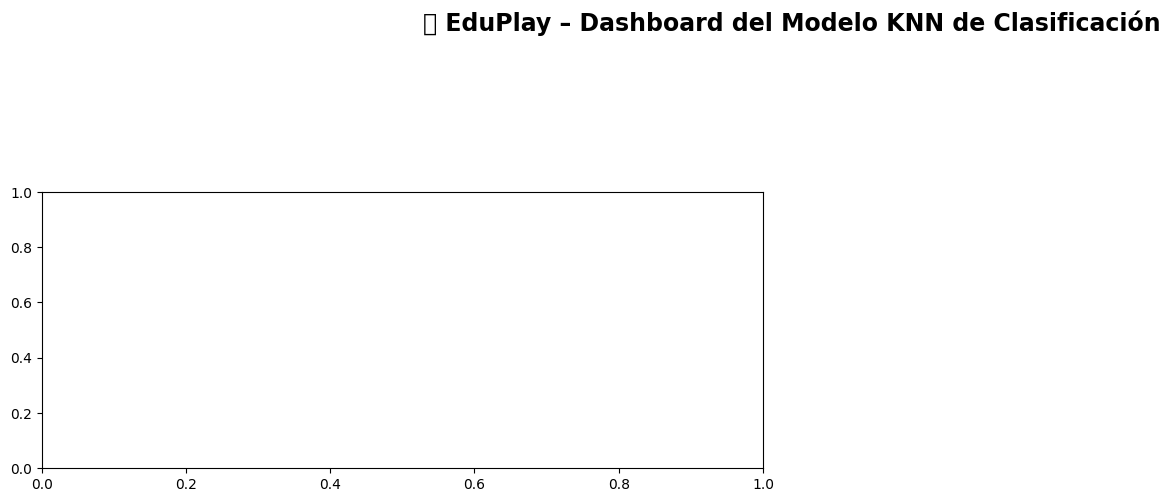

In [ ]:
# ============================================================
#  DASHBOARD FINAL – RESUMEN VISUAL DEL MODELO
# ============================================================
fig = plt.figure(figsize=(20, 14))
fig.suptitle('🎓 EduPlay – Dashboard del Modelo KNN de Clasificación',
             fontsize=17, fontweight='bold', y=1.01)

gs = fig.add_gridspec(3, 4, hspace=0.45, wspace=0.35)

# --- 1. Distribución predicha ---
ax1 = fig.add_subplot(gs[0, :2])
counts_knn = df['Rango_KNN'].value_counts().sort_index()
bars = ax1.bar([RANGE_LABELS[i-1] for i in counts_knn.index], counts_knn.values, color=[PALETTE[i-1] for i in counts_knn.index], edgecolor='white', linewidth=1.5)
for b, v in zip(bars, counts_knn.values):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 3,
             f'{v}', ha='center', fontsize=10, fontweight='bold')
ax1.set_title('Distribución de Alumnos por Rango (KNN)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Alumnos')

# --- 2. Puntuación promedio por área ---
ax2 = fig.add_subplot(gs[0, 2:])
means_area = df.groupby('Rango_KNN')[AREAS].mean()
x_pos = np.arange(len(AREAS))
width = 0.15
for i, (rango, color) in enumerate(zip(means_area.index, PALETTE)):
    ax2.bar(x_pos + i * width, means_area.loc[rango], width=width,
            color=color, alpha=0.85, label=RANGE_LABELS[rango-1])
ax2.set_xticks(x_pos + width * 2)
ax2.set_xticklabels([a[:4] for a in AREAS], fontsize=9)
ax2.set_title('Puntuación Media por Área y Rango', fontsize=12, fontweight='bold')
ax2.set_ylabel('Puntuación Media')
ax2.legend(fontsize=8, ncol=5, loc='upper right')

# --- 3. Violin plot por rango ---
ax3 = fig.add_subplot(gs[1, :2])
data_violin = [df[df['Rango_KNN'] == r]['Puntuacion_Promedio'].values for r in range(1, 6)]
vp = ax3.violinplot(data_violin[1:4], positions=[2, 3, 4], showmedians=True)
for body, color in zip(vp['bodies'], PALETTE[1:4]):
    body.set_facecolor(color)
    body.set_alpha(0.7)
ax3.set_xticks([2, 3, 4])
ax3.set_xticklabels(RANGE_LABELS[1:4], fontsize=9)
for body, color in zip(vp['bodies'], PALETTE):
    body.set_facecolor(color)
    body.set_alpha(0.7)
ax3.set_xticks(range(1, 6))
ax3.set_xticklabels(RANGE_LABELS, fontsize=9)
ax3.set_title('Distribución de Puntuación Promedio por Rango', fontsize=12, fontweight='bold')
ax3.set_ylabel('Puntuación Promedio')

# --- 4. Radar por rango ---
ax4 = fig.add_subplot(gs[1, 2:], polar=True)
angles = np.linspace(0, 2 * np.pi, len(AREAS), endpoint=False).tolist()
angles += angles[:1]
for rango, color, label in zip(means_area.index, PALETTE, RANGE_LABELS):
    values = means_area.loc[rango].values.tolist() + [means_area.loc[rango].values[0]]
    ax4.plot(angles, values, 'o-', linewidth=1.5, color=color, label=label)
    ax4.fill(angles, values, alpha=0.06, color=color)
ax4.set_xticks(angles[:-1])
ax4.set_xticklabels([a[:4] for a in AREAS], fontsize=8)
ax4.set_title('Radar de Competencias por Rango', fontsize=12, fontweight='bold', pad=20)
ax4.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)

# --- 5. Métricas del modelo ---
ax5 = fig.add_subplot(gs[2, :])
ax5.axis('off')
metrics_data = [
    ['Accuracy (Test)', f'{acc_test:.4f}', f'{acc_test*100:.2f}%'],
    ['Accuracy (CV 10-fold)', f'{best_cv_acc:.4f}', f'{best_cv_acc*100:.2f}%'],
    ['K óptimo', str(best_params.get("knn__n_neighbors", best_k)), '—'],
    ['Métrica de distancia', str(best_params.get("knn__metric", 'minkowski')), '—'],
    ['Ponderación', str(best_params.get("knn__weights", 'uniform')), '—'],
    ['Total alumnos', str(len(df)), '—'],
    ['Clases (Rangos)', '5', 'Crítico → Excelente'],
]
table = ax5.table(
    cellText=metrics_data,
    colLabels=['Métrica', 'Valor Numérico', 'Detalle'],
    cellLoc='center', loc='center',
    bbox=[0.1, 0.0, 0.8, 1.0]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#EBF5FB')
ax5.set_title('📋 Resumen de Hiperparámetros y Métricas del Modelo',
              fontsize=13, fontweight='bold', pad=15)

plt.savefig('dashboard_knn.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard guardado: dashboard_knn.png')

## 💾 10. Resumen Final y Archivos Generados

In [ ]:
# ============================================================
#  RESUMEN FINAL
# ============================================================
import os

archivos = [
    'EduPlay_Dataset.csv',
    'EduPlay_Dataset_Clasificado.csv',
    'histograma_variable_objetivo.png',
    'boxplots_areas.png',
    'mapa_calor.png',
    'curva_k_optimo.png',
    'matriz_confusion.png',
    'importancia_features.png',
    'dashboard_knn.png',
]

print('=' * 60)
print('          RESUMEN FINAL – EduPlay KNN Classifier')
print('=' * 60)
print(f'  Accuracy en Test     : {acc_test:.4f}  ({acc_test*100:.2f}%)')
print(f'  Accuracy CV 10-fold  : {best_cv_acc:.4f}  ({best_cv_acc*100:.2f}%)')
print(f'  K óptimo             : {best_params.get("knn__n_neighbors")}')
print(f'  Métrica              : {best_params.get("knn__metric")}')
print(f'  Ponderación          : {best_params.get("knn__weights")}')
print(f'  Total alumnos        : {len(df)}')
print(f'  Rangos clasificados  : 5 (Crítico → Excelente)')
print(f'\n📁 Archivos generados:')
for f in archivos:
    existe = '✅' if os.path.exists(f) else '⏳'
    print(f'   {existe} {f}')

print('\n🎓 Modelo EduPlay KNN – Version 0.1.0')
print('   EduPlay © 2026 | Desarrollado por EduData TecNM | Todos los derechos reservados')

          RESUMEN FINAL – EduPlay KNN Classifier


NameError: name 'acc_test' is not defined